In [1]:
!pip install pandas numpy matplotlib seaborn

In [4]:
!pip install gdown

In [6]:
try:
  import numpy as np
  import matplotlib.pyplot as plt
  import pandas as pd
  import seaborn as sns

  import gdown
  sns.set_style("darkgrid")

  print("Library Import Successfully")
except ImportError as e:
  print("Library Import Failed ", e)



Library Import Successfully


In [7]:
try:
    # Google Drive file IDs
    fear_greed_id = "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"
    trader_data_id = "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"

    # Direct download links
    fear_greed_url = f"https://drive.google.com/uc?id={fear_greed_id}"
    trader_data_url = f"https://drive.google.com/uc?id={trader_data_id}"

    # Download files
    gdown.download(fear_greed_url, "fear_greed.csv", quiet=False)
    gdown.download(trader_data_url, "trader_data.csv", quiet=False)

    print("Datasets downloaded successfully")

except Exception as e:
    print("Error downloading dataset:", e)

Downloading...
From: https://drive.google.com/uc?id=1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf
To: /content/fear_greed.csv
100%|██████████| 90.8k/90.8k [00:00<00:00, 41.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs
To: /content/trader_data.csv
100%|██████████| 47.5M/47.5M [00:00<00:00, 58.5MB/s]

Datasets downloaded successfully


**Load Dataset**

In [8]:
try:
  sentiment = pd.read_csv("fear_greed.csv")
  trades = pd.read_csv("trader_data.csv")

  print("Dataset Loaded Successfully")
  print(sentiment.head())
  print(trades.head())
except FileNotFoundError:
  print("Dataset not found")
except pd.errors.ParserError:
  print("CSV Parsering Error")
except Exception as e:
  print("Unexpected Error : ", e)

Dataset Loaded Successfully
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   115

In [9]:
try:
  print("Sentiment Dataset Info :")
  print(sentiment.info())

  print("Trader Dataset Info: ")
  print(trades.info())
except Exception as e:
  print("Error while Inspecting Dataset: ", e)

Sentiment Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None
Trader Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 no

In [10]:
try:
  sentiment.columns= sentiment.columns.str.lower().str.replace(" ", "_")
  trades.columns = trades.columns.str.lower().str.replace(" ", "_")

  print("Column Standardized ")

  print("\nSentiment Columns:", sentiment.columns)
  print("\nTraders Columns:", trades.columns)
except Exception as e:
  print("Error in Column name Formatting: ", e)

Column Standardized 

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Traders Columns: Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [12]:
try:
  sentiment['date'] = pd.to_datetime(sentiment['date'])
  trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'],
                                           dayfirst=True)

  trades['date']=trades['timestamp_ist'].dt.date
  sentiment['date']= sentiment['date'].dt.date

  print("Data Conversion is successfull")
except Exception as e:
  print("Data COnversion error : ", e)

Data Conversion is successfull


In [13]:
try:
  trades['win']= trades['closed_pnl'] > 0
  trades['loss'] = trades['closed_pnl'] < 0

  print("win/loss features added")
except Exception as e:
  print("Error while creating win/ loss feature")


win/loss features added


In [14]:
try:
    daily_stats = trades.groupby('date').agg({
        'closed_pnl': 'sum',
        'trade_id': 'count',
        'size_usd': 'sum',
        'fee': 'sum'
    }).reset_index()

    daily_stats.rename(columns={
        'closed_pnl': 'daily_pnl',
        'trade_id': 'trade_count',
        'size_usd': 'total_volume'
    }, inplace=True)

    print("Daily Trading Statistics Created")
    print(daily_stats.head())

except Exception as e:
    print("Aggregation Error : ", e)

Daily Trading Statistics Created
         date   daily_pnl  trade_count  total_volume        fee
0  2023-05-01    0.000000            3        477.00   0.000000
1  2023-12-05    0.000000            9      50005.83  12.501455
2  2023-12-14 -205.434737           11     113203.35  28.300831
3  2023-12-15  -24.632034            2      10609.95   2.652489
4  2023-12-16    0.000000            3      15348.77   3.837189


In [15]:
try:
    sentiment.rename(columns = {'classification' : 'sentiment'}, inplace=True)

    print(sentiment.head())

except Exception as e:
    print("Sentiment Processing Error : ", e)

    timestamp  value     sentiment        date
0  1517463000     30          Fear  2018-02-01
1  1517549400     15  Extreme Fear  2018-02-02
2  1517635800     40          Fear  2018-02-03
3  1517722200     24  Extreme Fear  2018-02-04
4  1517808600     11  Extreme Fear  2018-02-05


In [17]:
try:
    merged = pd.merge(daily_stats, sentiment, on='date', how='inner')

    print("Merge successful")
    print("Merged dataset shape:", merged.shape)
    print(merged.head())

except Exception as e:
    print("Merge error : ", e)

Merge successful
Merged dataset shape: (479, 8)
         date   daily_pnl  trade_count  total_volume        fee   timestamp  \
0  2023-05-01    0.000000            3        477.00   0.000000  1682919000   
1  2023-12-05    0.000000            9      50005.83  12.501455  1701754200   
2  2023-12-14 -205.434737           11     113203.35  28.300831  1702531800   
3  2023-12-15  -24.632034            2      10609.95   2.652489  1702618200   
4  2023-12-16    0.000000            3      15348.77   3.837189  1702704600   

   value      sentiment  
0     63          Greed  
1     75  Extreme Greed  
2     72          Greed  
3     70          Greed  
4     67          Greed  


In [18]:
try:
    pnl_by_sentiment = merged.groupby('sentiment')['daily_pnl'].mean()
    print(pnl_by_sentiment)

except Exception as e :
    print("Analysis error:", e)

sentiment
Extreme Fear     52793.589178
Extreme Greed    23817.292199
Fear             36891.818040
Greed            11140.566181
Neutral          19297.323516
Name: daily_pnl, dtype: float64


In [19]:
try:
    activity = merged.groupby('sentiment')['trade_count'].mean()
    print(activity)

except Exception as e:
    print("Activity Analysis Error : ", e)

sentiment
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trade_count, dtype: float64


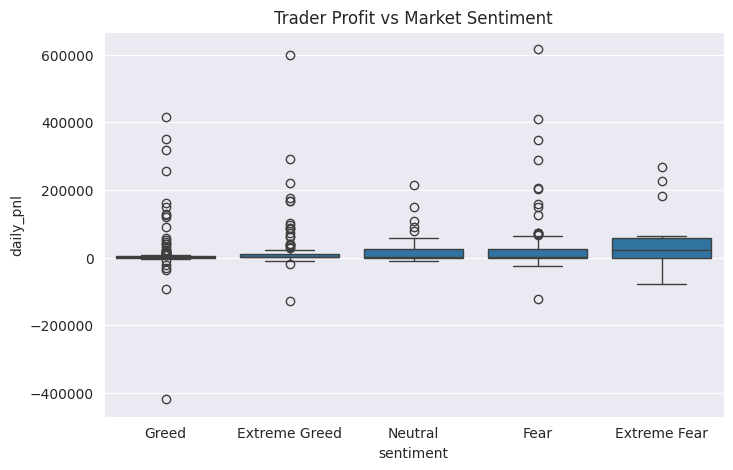

In [20]:
try:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='sentiment', y='daily_pnl', data=merged)
    plt.title("Trader Profit vs Market Sentiment")
    plt.show()

except Exception as e:
    print("Visualization error : ", e)

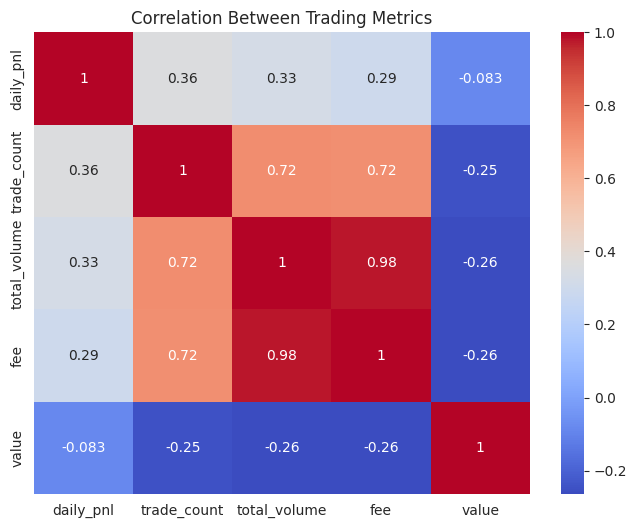

In [21]:
try:
    plt.figure(figsize=(8,6))
    corr = merged[['daily_pnl','trade_count','total_volume','fee','value']].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Between Trading Metrics")
    plt.show()

except Exception as e:
    print("Correlation Heatmap Error : ", e)

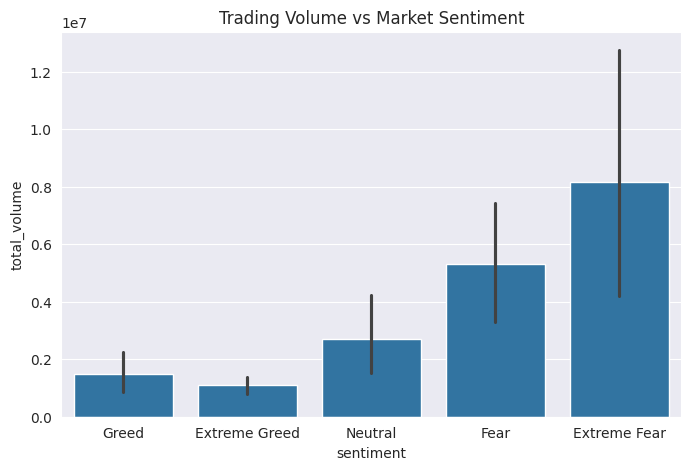

In [22]:
try:
    plt.figure(figsize=(8,5))
    sns.barplot(x='sentiment', y='total_volume', data=merged)
    plt.title("Trading Volume vs Market Sentiment")
    plt.show()

except Exception as e:
    print("Volume visualization error:", e)

In [23]:
try:
    volatility = merged.groupby('sentiment')['daily_pnl'].std()
    print("Profit Volatility by Sentiment")
    print(volatility)

except Exception as e:
    print("Volatility analysis error:", e)

Profit Volatility by Sentiment
sentiment
Extreme Fear     101262.394065
Extreme Greed     72827.301581
Fear              96611.848503
Greed             62427.957949
Neutral           37995.209071
Name: daily_pnl, dtype: float64


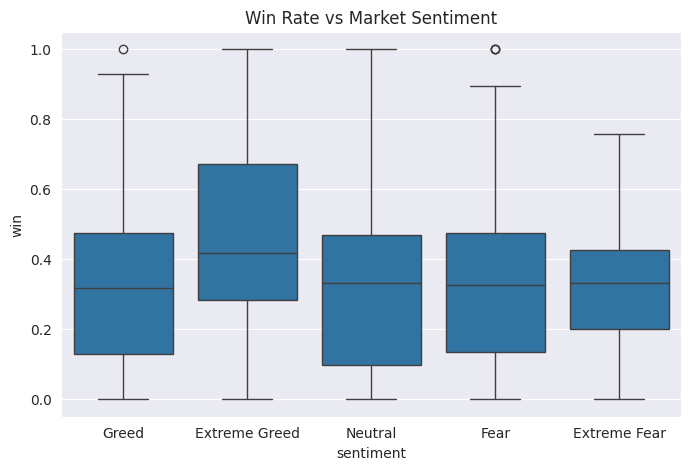

In [25]:
try:
    winrate = trades.groupby('date')['win'].mean().reset_index()
    winrate = pd.merge(winrate, sentiment, on='date', how='inner')
    plt.figure(figsize=(8,5))
    sns.boxplot(x='sentiment', y='win', data=winrate)
    plt.title("Win Rate vs Market Sentiment")
    plt.show()

except Exception as e:
    print("Win Rate Analysis Error : ", e)

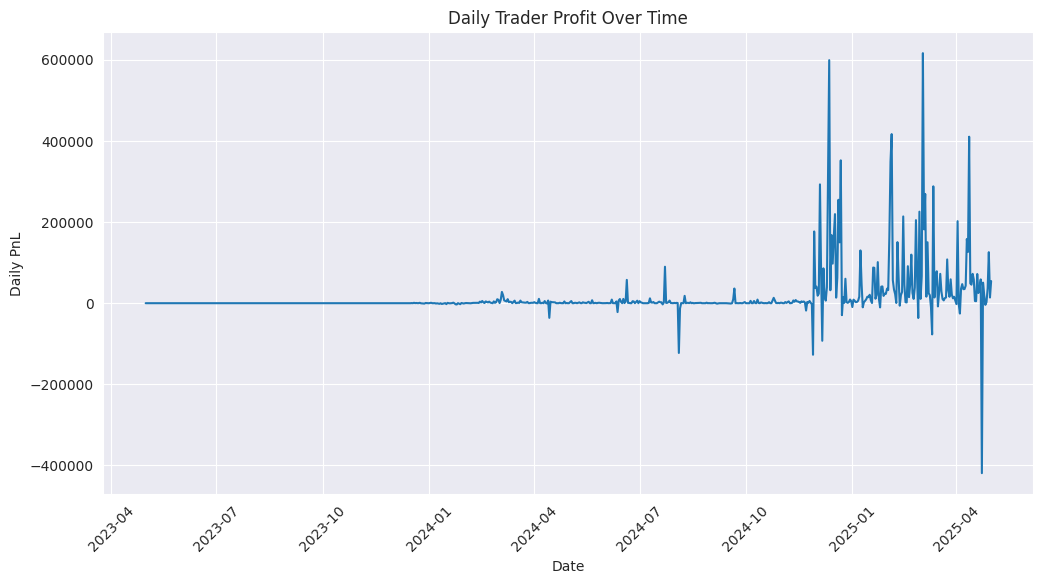

In [26]:
try:
    plt.figure(figsize=(12,6))
    plt.plot(merged['date'], merged['daily_pnl'])
    plt.xticks(rotation=45)
    plt.title("Daily Trader Profit Over Time")
    plt.xlabel("Date")
    plt.ylabel("Daily PnL")
    plt.show()

except Exception as e:
    print("Time series plot error:", e)

In [27]:
try:
    volatility= merged.groupby('sentiment')['daily_pnl'].std()
    print("Profit Volatility by Sentiment")
    print(volatility)

except Exception as e:
    print("Volatility Analysis Error : ", e)

Profit Volatility by Sentiment
sentiment
Extreme Fear     101262.394065
Extreme Greed     72827.301581
Fear              96611.848503
Greed             62427.957949
Neutral           37995.209071
Name: daily_pnl, dtype: float64


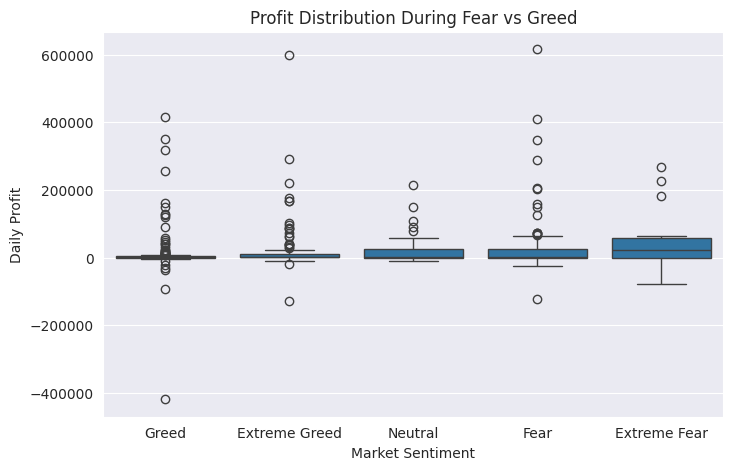

In [28]:
try:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='sentiment', y='daily_pnl', data=merged)
    plt.title("Profit Distribution During Fear vs Greed")

    plt.xlabel("Market Sentiment")
    plt.ylabel("Daily Profit")

    plt.show()

except Exception as e:
    print("Profit Distribution Error : ", e)

In [29]:
try:
    activity = merged.groupby('sentiment')['trade_count'].mean()
    print("Average Trades per Day by Sentiment")
    print(activity)

except Exception as e:
    print("Trading Activity Analysis Error : ", e)

Average Trades per Day by Sentiment
sentiment
Extreme Fear     1528.571429
Extreme Greed     350.807018
Fear              679.527473
Greed             260.637306
Neutral           562.477612
Name: trade_count, dtype: float64


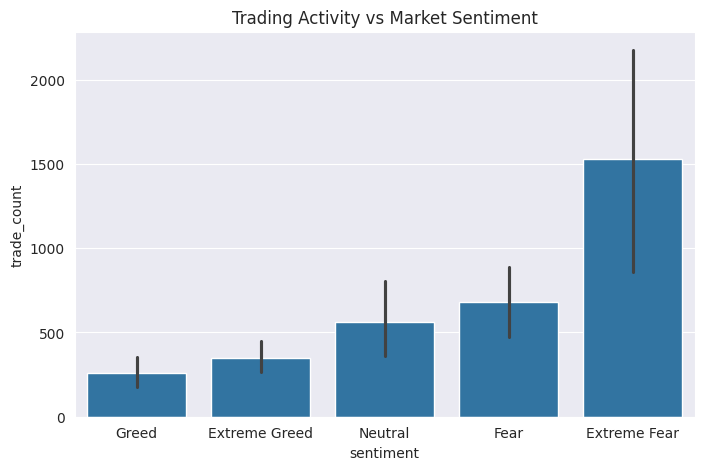

In [30]:
try:
    plt.figure(figsize=(8,5))
    sns.barplot(x='sentiment', y='trade_count', data=merged)
    plt.title("Trading Activity vs Market Sentiment")
    plt.show()

except Exception as e:
    print("Activity Plot Error:", e)

In [31]:
try:
    volume = merged.groupby('sentiment')['total_volume'].mean()
    print("Average Volume by Sentiment")
    print(volume)

except Exception as e:
    print("Volume Analysis Error : ", e)

Average Volume by Sentiment
sentiment
Extreme Fear     8.177447e+06
Extreme Greed    1.091800e+06
Fear             5.311261e+06
Greed            1.495246e+06
Neutral          2.690180e+06
Name: total_volume, dtype: float64


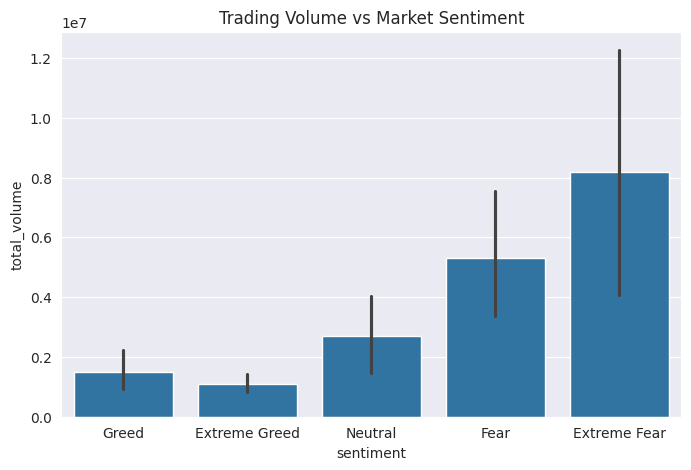

In [32]:
try:
    plt.figure(figsize=(8,5))
    sns.barplot(x='sentiment', y='total_volume', data=merged)
    plt.title("Trading Volume vs Market Sentiment")
    plt.show()

except Exception as e:
    print("Volume Plot Error : ", e)

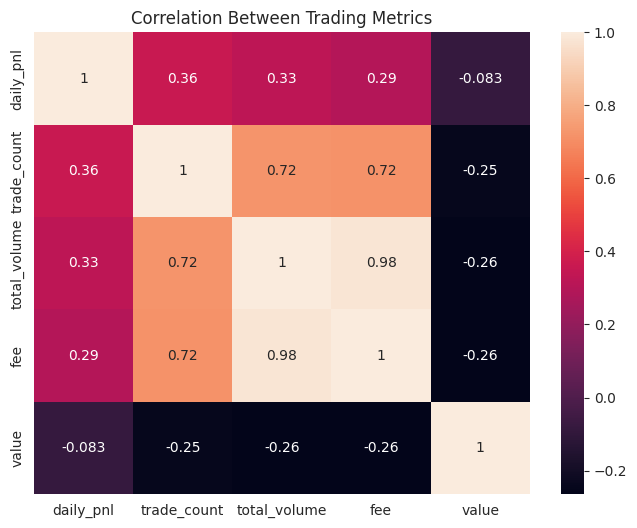

In [33]:
try:
    plt.figure(figsize=(8,6))
    corr = merged[['daily_pnl','trade_count','total_volume','fee','value']].corr()
    sns.heatmap(corr, annot=True)
    plt.title("Correlation Between Trading Metrics")
    plt.show()

except Exception as e:
    print("Correlation Heatmap Error : ", e)